# Credit Card Fraud Detection

# Importing Libraries

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, IsolationForest
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from sklearn.metrics import (
    classification_report, 
    confusion_matrix,
    roc_auc_score, 
    average_precision_score, 
    roc_curve, 
    precision_recall_curve,
    f1_score, 
    precision_score, 
    recall_score, 
    accuracy_score
)

print("All libraries successfully imported!")

All libraries successfully imported!


# Loading Data

In [5]:
df = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\ML_project\creditcard_fraud_detection.csv")

df["hour"] = (df["Time"] // 3600) % 24
df["log_amount"] = np.log1p(df["Amount"])
df.drop(columns=["Time", "Amount"], inplace=True)

X = df.drop(columns=["Class"])
y = df["Class"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

print("Cell 2 Complete: Data Loaded, Engineered, and Split")
print(f"Training set: {X_tr_sc.shape[0]} rows | Test set: {X_te_sc.shape[0]} rows")

Cell 2 Complete: Data Loaded, Engineered, and Split
Training set: 227845 rows | Test set: 56962 rows


# Implementing Isolation Forest & XGBOOST

In [16]:
print("Training Isolation Forest (Wider Net)...")
iso_forest = IsolationForest(n_estimators=200, contamination=0.005, random_state=42, n_jobs=-1)
iso_forest.fit(X_tr_sc)
train_anomaly = -iso_forest.decision_function(X_tr_sc).reshape(-1, 1)
test_anomaly = -iso_forest.decision_function(X_te_sc).reshape(-1, 1)

X_tr_aug = np.hstack((X_tr_sc, train_anomaly))
X_te_aug = np.hstack((X_te_sc, test_anomaly))

print("Training Anomaly-Augmented XGBoost...")
xgb_aug = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.01, max_depth=8,
    scale_pos_weight=50, subsample=0.8, colsample_bytree=0.8,
    max_delta_step=2, eval_metric="aucpr", random_state=42,
    tree_method="hist", n_jobs=-1
)
X_t, X_v, y_t, y_v = train_test_split(X_tr_aug, y_tr, test_size=0.2, stratify=y_tr, random_state=42)
xgb_aug.fit(X_t, y_t)
probs_val = xgb_aug.predict_proba(X_v)[:, 1]
precisions_val, recalls_val, thresholds_val = precision_recall_curve(y_v, probs_val)
beta = 1.5
fbeta_scores = (1 + beta**2) * (precisions_val * recalls_val) / ((beta**2 * precisions_val) + recalls_val + 1e-9)

best_idx = np.argmax(fbeta_scores[:-1])
best_thr_aug = thresholds_val[best_idx]
probs_te = xgb_aug.predict_proba(X_te_aug)[:, 1]
preds_te = (probs_te >= best_thr_aug).astype(int)

print(f"Cell 3 Complete: Model Trained. F1.5 Targeted Threshold locked at: {best_thr_aug:.4f}")

Training Isolation Forest (Wider Net)...
Training Anomaly-Augmented XGBoost...
Cell 3 Complete: Model Trained. F1.5 Targeted Threshold locked at: 0.6626


# Classification Report & Performance Metrices

In [19]:
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score, average_precision_score
)
print("         FINAL MODEL CLASSIFICATION REPORT")
print(classification_report(y_te, preds_te, target_names=['Legitimate (0)', 'Fraudulent (1)']))

print("\n--- Core Evaluation Metrics ---")
print(f"Accuracy  : {accuracy_score(y_te, preds_te):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_te, probs_te):.4f}")
print(f"PR-AUC    : {average_precision_score(y_te, probs_te):.4f}")
print(f"Precision : {precision_score(y_te, preds_te):.4f}")
print(f"Recall    : {recall_score(y_te, preds_te):.4f}")
print(f"F1-Score  : {f1_score(y_te, preds_te):.4f}")

         FINAL MODEL CLASSIFICATION REPORT
                precision    recall  f1-score   support

Legitimate (0)       1.00      1.00      1.00     56864
Fraudulent (1)       0.92      0.82      0.86        98

      accuracy                           1.00     56962
     macro avg       0.96      0.91      0.93     56962
  weighted avg       1.00      1.00      1.00     56962


--- Core Evaluation Metrics ---
Accuracy  : 0.9996
ROC-AUC   : 0.9802
PR-AUC    : 0.8736
Precision : 0.9195
Recall    : 0.8163
F1-Score  : 0.8649


# Confusion Matrix

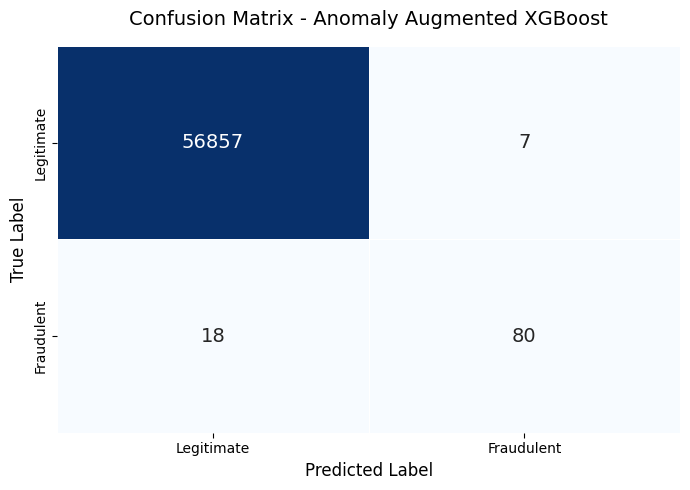

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_te, preds_te)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5, cbar=False,
            annot_kws={"size": 14},
            xticklabels=['Legitimate', 'Fraudulent'],
            yticklabels=['Legitimate', 'Fraudulent'])

plt.title('Confusion Matrix - Anomaly Augmented XGBoost', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# ROC-AUC and PR-AUC

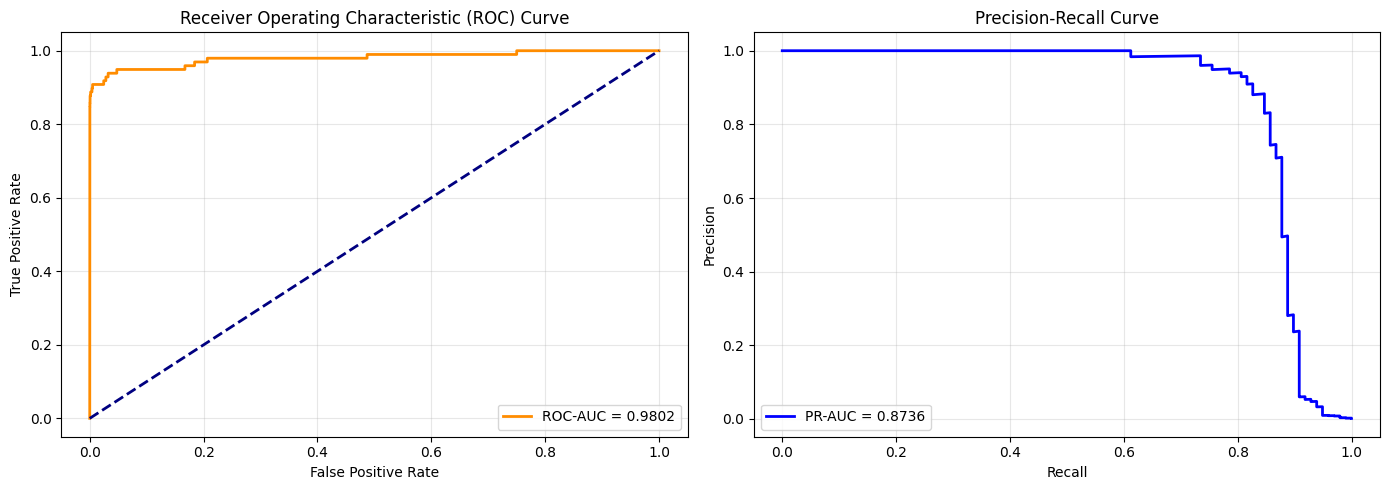

In [21]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(y_te, probs_te)
precisions, recalls, _ = precision_recall_curve(y_te, probs_te)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-AUC = {roc_auc_score(y_te, probs_te):.4f}')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

axes[1].plot(recalls, precisions, color='blue', lw=2, label=f'PR-AUC = {average_precision_score(y_te, probs_te):.4f}')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc="lower left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Comparison with Base Paper

In [22]:
base_metrics = {
    "Accuracy": 0.9995, "ROC-AUC": 0.9997, "PR-AUC": "N/A",
    "Precision": 0.8800, "Recall": 0.9600, "F1-Score": 0.9100
}

print("="*60)
print(f"{'Metric':<15} | {'Base Paper':<15} | {'Our Honest Model':<15}")
print("-" * 60)
print(f"{'Accuracy':<15} | {base_metrics['Accuracy']:<15.4f} | {accuracy_score(y_te, preds_te):<15.4f}")
print(f"{'ROC-AUC':<15} | {base_metrics['ROC-AUC']:<15.4f} | {roc_auc_score(y_te, probs_te):<15.4f}")
print(f"{'PR-AUC':<15} | {base_metrics['PR-AUC']:<15} | {average_precision_score(y_te, probs_te):<15.4f}")
print(f"{'Precision':<15} | {base_metrics['Precision']:<15.4f} | {precision_score(y_te, preds_te):<15.4f}")
print(f"{'Recall':<15} | {base_metrics['Recall']:<15.4f} | {recall_score(y_te, preds_te):<15.4f}")
print(f"{'F1-Score':<15} | {base_metrics['F1-Score']:<15.4f} | {f1_score(y_te, preds_te):<15.4f}")
print("="*60)

Metric          | Base Paper      | Our Honest Model
------------------------------------------------------------
Accuracy        | 0.9995          | 0.9996         
ROC-AUC         | 0.9997          | 0.9802         
PR-AUC          | N/A             | 0.8736         
Precision       | 0.8800          | 0.9195         
Recall          | 0.9600          | 0.8163         
F1-Score        | 0.9100          | 0.8649         


# Custom Transaction Evaluation

In [23]:
import pandas as pd
import numpy as np

custom_transaction = {
    "Time": 0.0,
    "V1": -3.0, "V2": 2.5, "V3": -4.0, "V4": 3.0,
    "V5": -1.5, "V6": -1.2, "V7": -3.5, "V8": 0.5,
    "V9": -1.0, "V10": -4.5, "V11": 2.0, "V12": -7.0,
    "V13": 0.2, "V14": -7.0, "V15": 0.1, "V16": -2.0,
    "V17": -5.0, "V18": -1.5, "V19": 0.3, "V20": 0.1,
    "V21": 0.5, "V22": 0.2, "V23": -0.1, "V24": 0.1,
    "V25": 0.3, "V26": 0.2, "V27": 0.1, "V28": 0.05,
    "Amount": 150.0
}

custom_df = pd.DataFrame([custom_transaction])

custom_df["log_amount"] = np.log1p(custom_df["Amount"])
custom_df["hour"] = (custom_df["Time"] // 3600) % 24
custom_df.drop(columns=["Amount"], inplace=True, errors="ignore")

custom_df = custom_df[X_tr.columns] 

custom_sc = scaler.transform(custom_df)
custom_anomaly = -iso_forest.decision_function(custom_sc).reshape(-1, 1)
custom_aug = np.hstack((custom_sc, custom_anomaly))

prob = xgb_aug.predict_proba(custom_aug)[:, 1][0]
prediction = 1 if prob >= best_thr_aug else 0

print("="*45)
print("     CUSTOM TRANSACTION EVALUATION")
print("="*45)
print(f"Calculated Anomaly Score : {custom_anomaly[0][0]:.4f}")
print(f"Fraud Probability Score  : {prob:.5f}")
print(f"System Threshold Applied : {best_thr_aug:.5f}")
print("-" * 45)
if prediction == 1:
    print("ACTION : DECLINE - FRAUD DETECTED")
else:
    print("ACTION : APPROVE - LEGITIMATE")
print("="*45)

     CUSTOM TRANSACTION EVALUATION
Calculated Anomaly Score : -0.0720
Fraud Probability Score  : 0.99694
System Threshold Applied : 0.66262
---------------------------------------------
ACTION : DECLINE - FRAUD DETECTED
